# 📊 Olist Retail Sales Performance Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##  ⬇️ Loading csv data in Dataframes.

In [2]:
customer_df = pd.read_csv(f"..\\Dataset\\olist_customers_dataset.csv")
print("\n✅customer_df is loaded with olist_customers_dataset.csv 👥\n\n")

geolocation_df = pd.read_csv(f"..\\Dataset\\olist_geolocation_dataset.csv")
print("✅geolocation_df is loaded with olist_geolocation_dataset.csv 📍\n\n")

order_items_df = pd.read_csv(f"..\\Dataset\\olist_order_items_dataset.csv")
print("✅order_items_df is loaded with olist_order_items_dataset.csv 📦\n\n")

order_payments_df = pd.read_csv(f"..\\Dataset\\olist_order_payments_dataset.csv")
print("✅order_payments_df is loaded with olist_order_payments_dataset.csv 💳\n\n")

order_reviews_df = pd.read_csv(f"..\\Dataset\\olist_order_reviews_dataset.csv")
print("✅order_reviews_df is loaded with olist_order_reviews_dataset.csv ⭐\n\n")

orders_df = pd.read_csv(f"..\\Dataset\\olist_orders_dataset.csv")
print("✅orders_df is loaded with olist_orders_dataset.csv 📋\n\n")

products_df = pd.read_csv(f"..\\Dataset\\olist_products_dataset.csv")
print("✅products_df is loaded with olist_products_dataset.csv 🏷️\n\n")

sellers_df = pd.read_csv(f"..\\Dataset\\olist_sellers_dataset.csv")
print("✅sellers_df is loaded with olist_sellers_dataset.csv 🏪\n\n")

product_category_name_translation_df = pd.read_csv(f"..\\Dataset\\product_category_name_translation.csv")
print("✅product_category_name_translation_df is loaded with product_category_name_translation.csv 🔤\n\n")


✅customer_df is loaded with olist_customers_dataset.csv 👥


✅geolocation_df is loaded with olist_geolocation_dataset.csv 📍


✅order_items_df is loaded with olist_order_items_dataset.csv 📦


✅order_payments_df is loaded with olist_order_payments_dataset.csv 💳


✅order_reviews_df is loaded with olist_order_reviews_dataset.csv ⭐


✅orders_df is loaded with olist_orders_dataset.csv 📋


✅products_df is loaded with olist_products_dataset.csv 🏷️


✅sellers_df is loaded with olist_sellers_dataset.csv 🏪


✅product_category_name_translation_df is loaded with product_category_name_translation.csv 🔤




## # Columns in each dataframe.

In [3]:
df={
    "customer_df":customer_df,
    "geolocation_df":geolocation_df,
    "order_items_df":order_items_df,
    "order_payments_df":order_payments_df,
    "order_reviews_df":order_reviews_df,
    "orders_df":orders_df,
    "products_df":products_df,
    "sellers_df":sellers_df,
    "product_category_name_translation_df":product_category_name_translation_df
    }

In [4]:
for df_key,df_value in df.items():
    print(f"The {df_key} has {df_value.shape[0]} rows and {df_value.shape[1]} columns\n\n")

The customer_df has 99441 rows and 5 columns


The geolocation_df has 1000163 rows and 5 columns


The order_items_df has 112650 rows and 7 columns


The order_payments_df has 103886 rows and 5 columns


The order_reviews_df has 99224 rows and 7 columns


The orders_df has 99441 rows and 8 columns


The products_df has 32951 rows and 9 columns


The sellers_df has 3095 rows and 4 columns


The product_category_name_translation_df has 71 rows and 2 columns




In [5]:
for df_key,df_value in df.items():
    quote=[f"{col}" for col in df_value ]
    total_col=len(quote)
    join_col=', '.join(quote)
    print(f'{df_key} has {total_col} columns i.e {join_col}\n\n')

customer_df has 5 columns i.e customer_id, customer_unique_id, customer_zip_code_prefix, customer_city, customer_state


geolocation_df has 5 columns i.e geolocation_zip_code_prefix, geolocation_lat, geolocation_lng, geolocation_city, geolocation_state


order_items_df has 7 columns i.e order_id, order_item_id, product_id, seller_id, shipping_limit_date, price, freight_value


order_payments_df has 5 columns i.e order_id, payment_sequential, payment_type, payment_installments, payment_value


order_reviews_df has 7 columns i.e review_id, order_id, review_score, review_comment_title, review_comment_message, review_creation_date, review_answer_timestamp


orders_df has 8 columns i.e order_id, customer_id, order_status, order_purchase_timestamp, order_approved_at, order_delivered_carrier_date, order_delivered_customer_date, order_estimated_delivery_date


products_df has 9 columns i.e product_id, product_category_name, product_name_lenght, product_description_lenght, product_photos_qty, p

In [6]:
for df_key,df_value in df.items():
    duplicated=df_value[df_value.duplicated].shape
    print(f"{duplicated[0]} rows are duplicate in {df_value.shape[0]} rows {df_value.shape[0] - duplicated[0]} rows are unique & {duplicated[1]} columns of {df_key}.\n\n")

0 rows are duplicate in 99441 rows 99441 rows are unique & 5 columns of customer_df.


261831 rows are duplicate in 1000163 rows 738332 rows are unique & 5 columns of geolocation_df.


0 rows are duplicate in 112650 rows 112650 rows are unique & 7 columns of order_items_df.


0 rows are duplicate in 103886 rows 103886 rows are unique & 5 columns of order_payments_df.


0 rows are duplicate in 99224 rows 99224 rows are unique & 7 columns of order_reviews_df.


0 rows are duplicate in 99441 rows 99441 rows are unique & 8 columns of orders_df.


0 rows are duplicate in 32951 rows 32951 rows are unique & 9 columns of products_df.


0 rows are duplicate in 3095 rows 3095 rows are unique & 4 columns of sellers_df.


0 rows are duplicate in 71 rows 71 rows are unique & 2 columns of product_category_name_translation_df.




## 👥 Customer Dataframe Analysis

In [7]:
customer_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB


In [8]:
summary=customer_df.describe().T
summary['IQR']=summary['75%']-summary['25%']
summary

,count,mean,std,min,25%,50%,75%,max,IQR
customer_zip_code_prefix,99441.0,35137.474583,29797.938996,1003.0,11347.0,24416.0,58900.0,99990.0,47553.0


In [9]:
customer_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [10]:
customer_df.tail()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS
99440,274fa6071e5e17fe303b9748641082c8,84732c5050c01db9b23e19ba39899398,6703,cotia,SP


In [11]:
missing_summary={
    "Missing Count": customer_df.isna().sum(),
    "Missing Percentage" :customer_df.isnull().mean() * 100
}
print(f'Missing Count:\n{missing_summary["Missing Count"]}\n\nMissing Percentage:\n{missing_summary["Missing Percentage"]}')

Missing Count:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Missing Percentage:
customer_id                 0.0
customer_unique_id          0.0
customer_zip_code_prefix    0.0
customer_city               0.0
customer_state              0.0
dtype: float64


In [12]:
duplicated=customer_df[customer_df.duplicated].shape
print(f"There are {duplicated[0]} rows in {duplicated[1]} columns of Customer table.")

There are 0 rows in 5 columns of Customer table.


In [13]:
duplicated=customer_df[customer_df.duplicated].shape
print(f"There are {duplicated[0]} rows in {duplicated[1]} columns of Customer table.")

There are 0 rows in 5 columns of Customer table.


In [14]:
customer_df.dtypes

customer_id                   str
customer_unique_id            str
customer_zip_code_prefix    int64
customer_city                 str
customer_state                str
dtype: object

In [15]:
for i in customer_df.columns:
    x=customer_df[i].is_unique
    if x == True:
        print(f'{i} is unique')
    if x == False:
        print(f'{i} is not unique')

customer_id is unique
customer_unique_id is not unique
customer_zip_code_prefix is not unique
customer_city is not unique
customer_state is not unique


In [16]:
customer_df.nunique()

customer_id                 99441
customer_unique_id          96096
customer_zip_code_prefix    14994
customer_city                4119
customer_state                 27
dtype: int64

<Axes: title={'center': 'Customer City frequency count of Top 10 city'}, xlabel='count', ylabel='customer_city'>

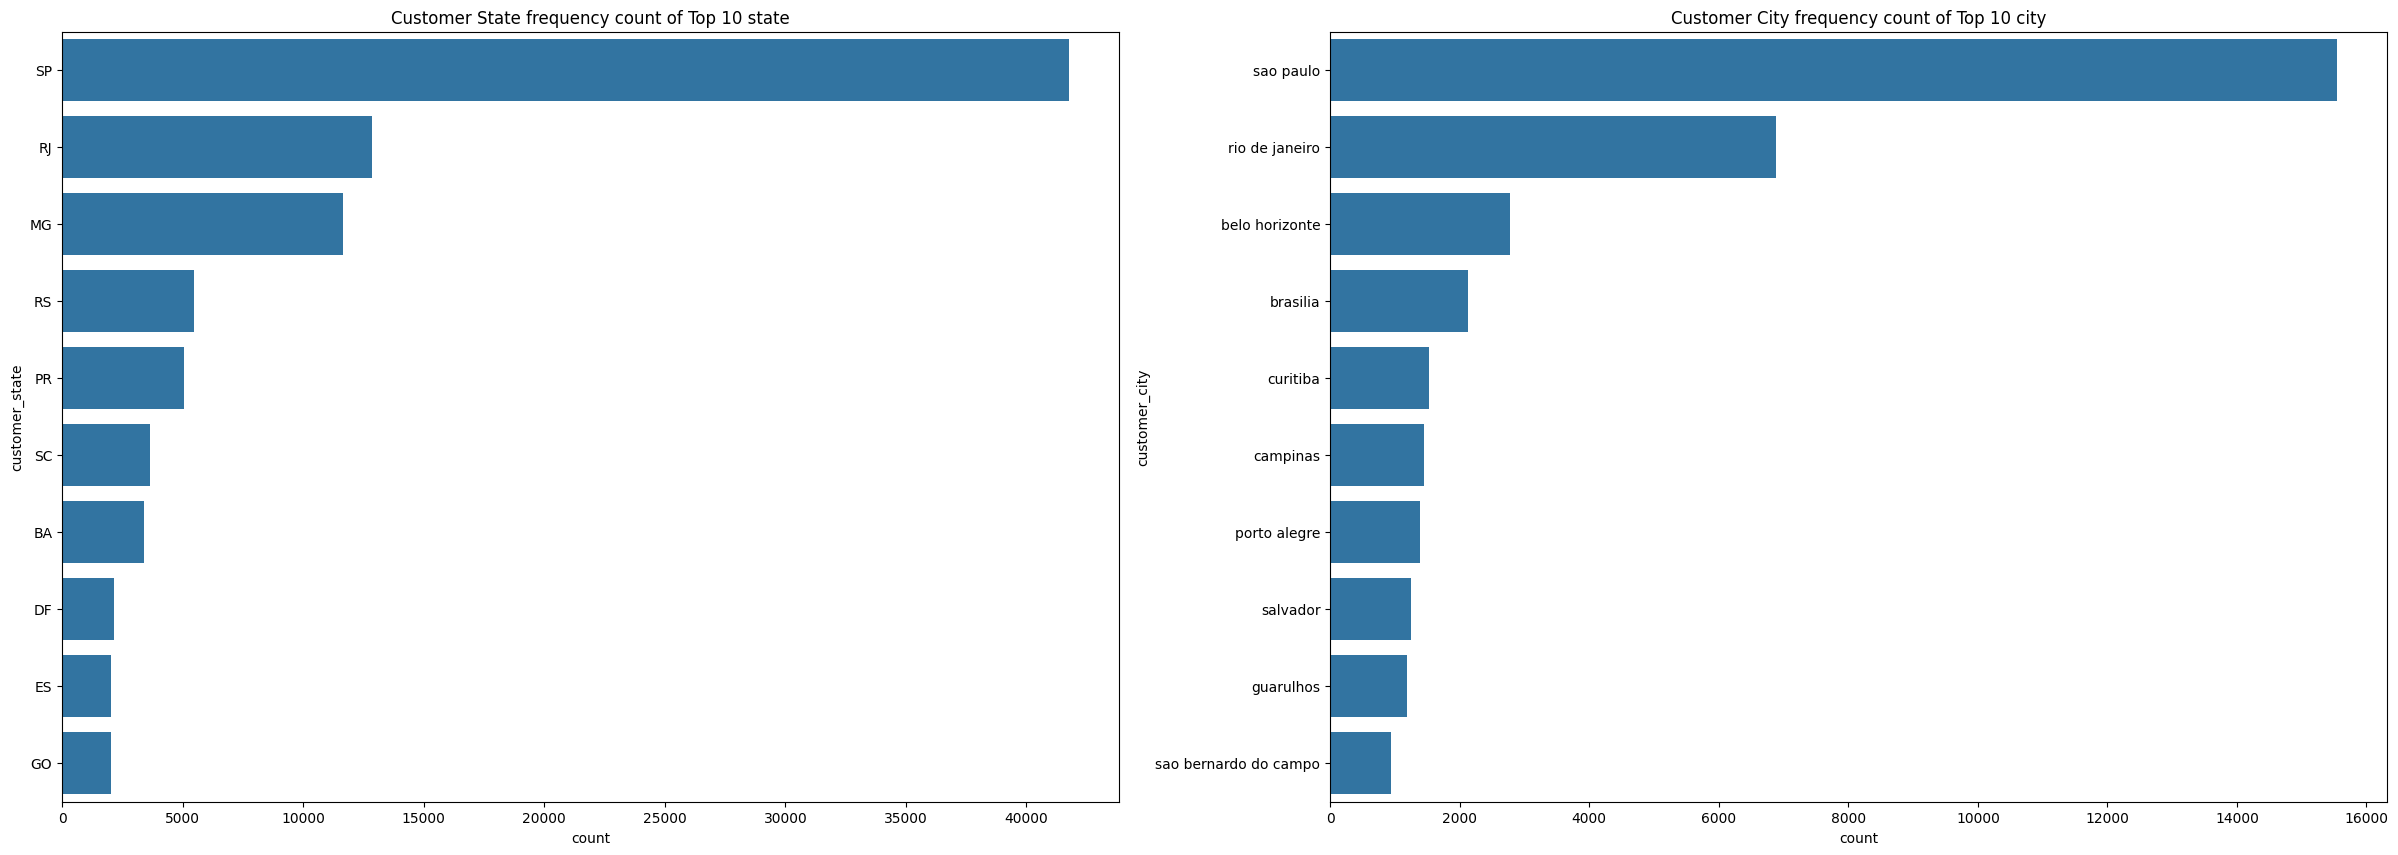

In [17]:
plt.figure(figsize=(30,10))
plt.subplot(1,2,1)
plt.title('Customer State frequency count of Top 10 state')
sns.countplot(data=customer_df,y='customer_state',order=customer_df['customer_state'].value_counts().head(10).index)
plt.subplot(1,2,2)
plt.title('Customer City frequency count of Top 10 city')
sns.countplot(data=customer_df,y='customer_city',order=customer_df['customer_city'].value_counts().head(10).index)

## Summary of Customer Analysis 

* Custommer data has 99441 rows with 0 duplicated values.
* There is 0% missing values.
* customer_id(99441) is unique and customer_unique_id(96096), customer_zip_code_prefix(14994), customer_city(4119), customer_state(27) are not unique.
(***note:*** The column name with there unique/distinct value count is given).
* we found 19 cities with mismatch name with zipcode.

### Data cleanning

In [18]:
unique_city=customer_df['customer_city'].sort_values(ascending=True).unique()
len(unique_city)

4119

In [19]:
customer_df['customer_city'] = customer_df['customer_city'].str.strip().str.lower()

In [20]:
# 1. Find the dominant city name spelling for each zip code
dominant_city_mapping = (
    customer_df.groupby('customer_zip_code_prefix')['customer_city']
    .agg(lambda x: x.mode()[0] if not x.mode().empty else None)
)

# 2. Overwrite the typos across the entire dataframe at once
customer_df['customer_city'] = customer_df['customer_zip_code_prefix'].map(dominant_city_mapping)

In [21]:
print(f"Number of unique cities before: {len(unique_city)}")
print(f"Number of unique cities now: {customer_df['customer_city'].nunique()}")

Number of unique cities before: 4119
Number of unique cities now: 4100


### Storing the data in csv

In [22]:
customer_df.to_csv("..\\Cleaned_Dataset\\cleaned_customer.csv",index=False)

## 📍 Geolocation Dataframe Analysis

In [23]:
geolocation_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  str    
 4   geolocation_state            1000163 non-null  str    
dtypes: float64(2), int64(1), str(2)
memory usage: 38.2 MB


In [24]:
summary=geolocation_df.describe().T
summary['IQR']=summary['75%']-summary['25%']
summary

,count,mean,std,min,25%,50%,75%,max,IQR
geolocation_zip_code_prefix,1000163.0,36574.166466,30549.335710,1001.000000,11075.000000,26530.000000,63504.000000,99990.000000,52429.000000
geolocation_lat,1000163.0,-21.176153,5.715866,-36.605374,-23.603546,-22.919377,-19.979620,45.065933,3.623925
geolocation_lng,1000163.0,-46.390541,4.269748,-101.466766,-48.573172,-46.637879,-43.767709,121.105394,4.805463


In [25]:
geolocation_df.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [26]:
geolocation_df.tail()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
1000158,99950,-28.068639,-52.010705,tapejara,RS
1000159,99900,-27.877125,-52.224882,getulio vargas,RS
1000160,99950,-28.071855,-52.014716,tapejara,RS
1000161,99980,-28.388932,-51.846871,david canabarro,RS
1000162,99950,-28.070104,-52.018658,tapejara,RS


In [27]:
missing_summary={
    "Missing Count": geolocation_df.isna().sum(),
    "Missing Percentage" :geolocation_df.isnull().mean() * 100
}
print(f'Missing Count:\n{missing_summary["Missing Count"]}\n\nMissing Percentage:\n{missing_summary["Missing Percentage"]}')

Missing Count:
geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

Missing Percentage:
geolocation_zip_code_prefix    0.0
geolocation_lat                0.0
geolocation_lng                0.0
geolocation_city               0.0
geolocation_state              0.0
dtype: float64


In [28]:
duplicated=geolocation_df[geolocation_df.duplicated].shape
print(f"There are {duplicated[0]} rows in {duplicated[1]} columns of Customer table.")

There are 261831 rows in 5 columns of Customer table.


In [29]:
for i in geolocation_df.columns:
    geolocation_df[i].is_unique
    if geolocation_df[i].is_unique==True:
        print(f'{i} is unique')
    if geolocation_df[i].is_unique==False:
        print(f'{i} is not unique')

geolocation_zip_code_prefix is not unique
geolocation_lat is not unique
geolocation_lng is not unique
geolocation_city is not unique
geolocation_state is not unique


In [30]:
geolocation_df.nunique()

geolocation_zip_code_prefix     19015
geolocation_lat                717360
geolocation_lng                717613
geolocation_city                 8011
geolocation_state                  27
dtype: int64

In [31]:
geolocation_df.duplicated().sum()

np.int64(261831)

## Summary of Geolocation Analysis

* The geolocation data has 0% missing value with 261831 duplicated rows.
* All columns in this data is not unique.
* geolocation_zip_code_prefix(19015), geolocation_lat(717360), geolocation_lng(717613),geolocation_city(8011), geolocation_state(21). 
- (***note:*** The column name with there unique/distinct value count is given).

### Data cleaning

In [32]:
# 1. Inspect the initial shape
print(f"Original shape: {geolocation_df.shape}")

# 2. Group by zip code prefix and aggregate coordinates
# We use 'mean' for latitude/longitude and 'first' for the textual city and state names
cleaned_geolocation = geolocation_df.groupby('geolocation_zip_code_prefix').agg({
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean',
    'geolocation_city': 'first',   # Retains the most frequent/first recorded city name
    'geolocation_state': 'first'   # Retains the corresponding state abbreviation
}).reset_index()

# 3. Verify that the zip code prefix is now completely unique
print(f"Cleaned shape (unique zip codes): {cleaned_geolocation.shape}")
print(f"Is zip code unique? {cleaned_geolocation['geolocation_zip_code_prefix'].is_unique}")

# Optional: Clean up text inconsistencies in cities (e.g., lowercase / accents)
cleaned_geolocation['geolocation_city'] = cleaned_geolocation['geolocation_city'].str.strip().str.lower()

# Now `cleaned_geolocation` is perfectly safe to merge with your customer or seller dataframes!

Original shape: (1000163, 5)
Cleaned shape (unique zip codes): (19015, 5)
Is zip code unique? True


In [33]:
# Bounding box coordinates for Brazil boundaries
brazil_geo = cleaned_geolocation[
    (cleaned_geolocation['geolocation_lat'] <= 5.27) & (cleaned_geolocation['geolocation_lat'] >= -33.75) &
    (cleaned_geolocation['geolocation_lng'] <= -34.79) & (cleaned_geolocation['geolocation_lng'] >= -73.98)
]

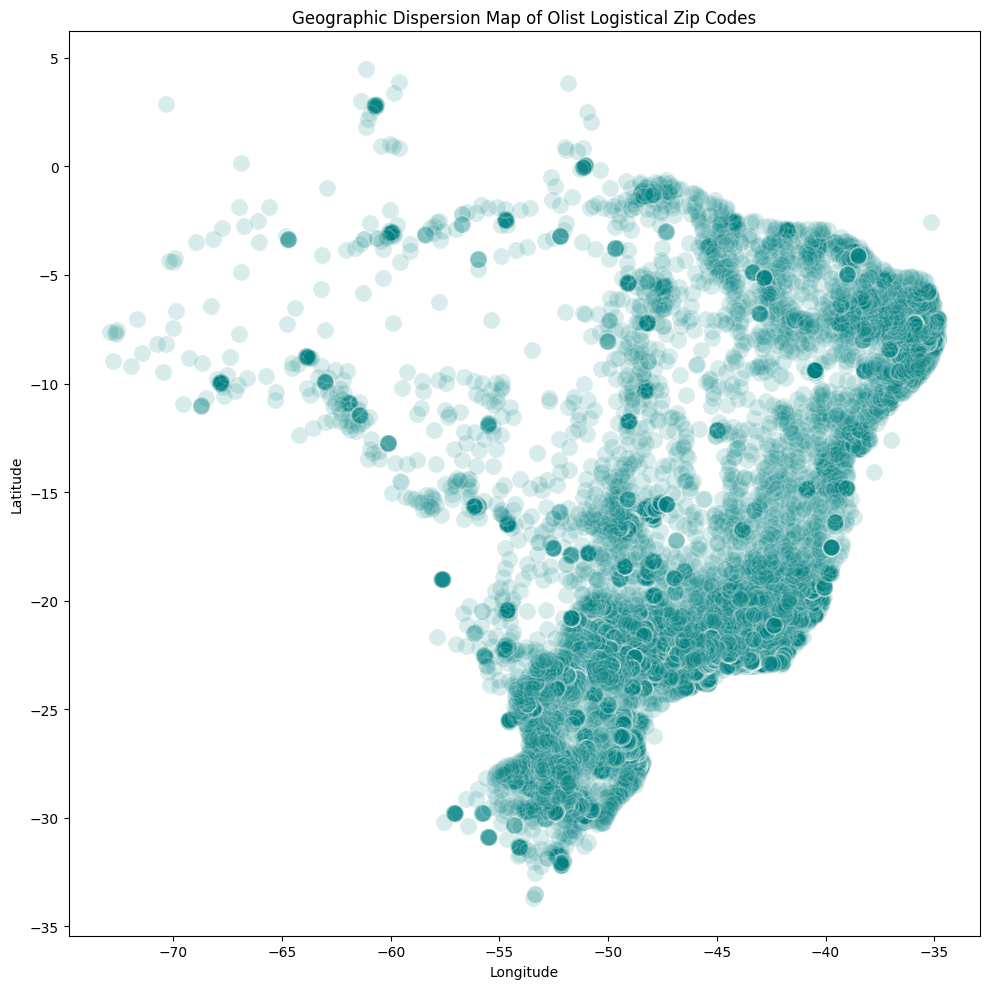

In [34]:
plt.figure(figsize=(10, 10))
sns.scatterplot(
    data=brazil_geo, 
    x='geolocation_lng', 
    y='geolocation_lat', 
    alpha=0.15, 
    s=150, 
    color='teal'
)
plt.title('Geographic Dispersion Map of Olist Logistical Zip Codes')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.axis('equal')
plt.tight_layout()
plt.show()

In [35]:
cleaned_geolocation.duplicated().sum()

np.int64(0)

In [36]:
cleaned_geolocation.to_csv("..\\Cleaned_Dataset\\cleaned_geolocation.csv",index=False)

## 📦 Order Items Datafeame Analysis

In [37]:
order_items_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 6.0 MB


In [38]:
summary=order_items_df.describe().T
summary['IQR']=summary['75%']-summary['25%']
summary

,count,mean,std,min,25%,50%,75%,max,IQR
order_item_id,112650.0,1.197834,0.705124,1.00,1.00,1.00,1.00,21.00,0.00
price,112650.0,120.653739,183.633928,0.85,39.90,74.99,134.90,6735.00,95.00
freight_value,112650.0,19.990320,15.806405,0.00,13.08,16.26,21.15,409.68,8.07


In [39]:
missing_summary={
    'Missing Count': order_items_df.isnull().sum(),
    'Missing Percentage': order_items_df.isnull().mean()*100
}

print(f'Missing Count:\n{missing_summary["Missing Count"]}\n\nMissing Percentage:\n{missing_summary["Missing Percentage"]}')

Missing Count:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Missing Percentage:
order_id               0.0
order_item_id          0.0
product_id             0.0
seller_id              0.0
shipping_limit_date    0.0
price                  0.0
freight_value          0.0
dtype: float64


In [40]:
order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [41]:
order_items_df.tail()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72
112649,fffe41c64501cc87c801fd61db3f6244,1,350688d9dc1e75ff97be326363655e01,f7ccf836d21b2fb1de37564105216cc1,2018-06-12 17:10:13,43.00,12.79


In [42]:
order_items_df.dtypes

order_id                   str
order_item_id            int64
product_id                 str
seller_id                  str
shipping_limit_date        str
price                  float64
freight_value          float64
dtype: object

In [43]:
Q1 = order_items_df['price'].quantile(0.25)
Q3 = order_items_df['price'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Price IQR: {IQR}")
print(f"Upper Bound for Outliers: {upper_bound:.2f}")

# Count outliers
outliers = order_items_df[order_items_df['price'] > upper_bound]
print(f"Number of upper outliers: {len(outliers)} ({len(outliers)/len(order_items_df)*100:.2f}%)")

Price IQR: 95.0
Upper Bound for Outliers: 277.40
Number of upper outliers: 8427 (7.48%)


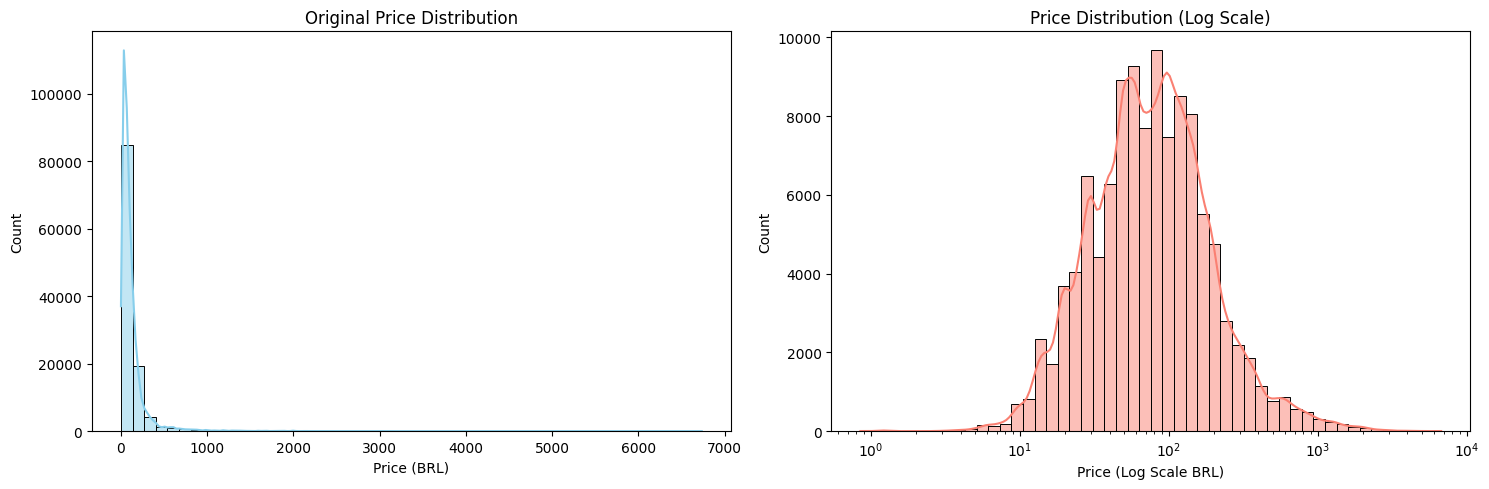

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(order_items_df['price'], bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Original Price Distribution')
axes[0].set_xlabel('Price (BRL)')
axes[0].set_ylabel('Count')

sns.histplot(order_items_df['price'], bins=50, kde=True, ax=axes[1], color='salmon', log_scale=True)
axes[1].set_title('Price Distribution (Log Scale)')
axes[1].set_xlabel('Price (Log Scale BRL)')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()

In [45]:
Q1 = order_items_df['freight_value'].quantile(0.25)
Q3 = order_items_df['freight_value'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"freight_value IQR: {IQR}")
print(f"Upper Bound for Outliers: {upper_bound:.2f}")

# Count outliers
outliers = order_items_df[order_items_df['freight_value'] > upper_bound]
print(f"Number of upper outliers: {len(outliers)} ({len(outliers)/len(order_items_df)*100:.2f}%)")


freight_value IQR: 8.069999999999999
Upper Bound for Outliers: 33.25
Number of upper outliers: 11613 (10.31%)


In [46]:
for i in order_items_df.columns:
    order_items_df[i].is_unique
    if order_items_df[i].is_unique==True:
        print(f'{i} is unique')
    if order_items_df[i].is_unique==False:
        print(f'{i} is not unique')

order_id is not unique
order_item_id is not unique
product_id is not unique
seller_id is not unique
shipping_limit_date is not unique
price is not unique
freight_value is not unique


In [47]:
order_items_df.nunique()

order_id               98666
order_item_id             21
product_id             32951
seller_id               3095
shipping_limit_date    93318
price                   5968
freight_value           6999
dtype: int64

## Summary of Order Items Analysis

* Order item has 0% missing values with 0 duplicated values.
* Shipping_limit_date is given in string we have to convert it into datetime.
* Price column have 8427 outliers that is 7.48% of data.
* Hisplot of the price is left skewed.
* Freight value has 11613 outlier that is 10.31% of the data.
* All column in Order Item data are not unique.
* order_id(98666), order_item_id(21), product_id(32951), seller_id(3095), shipping_limit_date(93318), price(5968), freight_value(6999)
- (***note:*** The column name with there unique/distinct value count is given).

### Data Cleaning

In [48]:
order_items_df['shipping_limit_date']=pd.to_datetime(order_items_df['shipping_limit_date'])

In [49]:
order_items_df.dtypes

order_id                          str
order_item_id                   int64
product_id                        str
seller_id                         str
shipping_limit_date    datetime64[us]
price                         float64
freight_value                 float64
dtype: object

In [50]:
summary_stats=order_items_df[['price','freight_value']].describe(percentiles=[0.25,0.5,0.75,0.90,0.95,0.99])
print(summary_stats)

               price  freight_value
count  112650.000000  112650.000000
mean      120.653739      19.990320
std       183.633928      15.806405
min         0.850000       0.000000
25%        39.900000      13.080000
50%        74.990000      16.260000
75%       134.900000      21.150000
90%       229.800000      34.041000
95%       349.900000      45.120000
99%       890.000000      84.520000
max      6735.000000     409.680000


In [51]:
order_items_df.to_csv("..\\Cleaned_Dataset\\cleaned_order_item.csv",index=False)

## ⭐ Order Review Dataframe Analysis

In [52]:
order_reviews_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   review_id                99224 non-null  str  
 1   order_id                 99224 non-null  str  
 2   review_score             99224 non-null  int64
 3   review_comment_title     11568 non-null  str  
 4   review_comment_message   40977 non-null  str  
 5   review_creation_date     99224 non-null  str  
 6   review_answer_timestamp  99224 non-null  str  
dtypes: int64(1), str(6)
memory usage: 5.3 MB


In [53]:
order_reviews_df.describe().T

,count,mean,std,min,25%,50%,75%,max
review_score,99224.0,4.086421,1.347579,1.0,4.0,5.0,5.0,5.0


In [54]:
missing_summary = {
    'Missing Count': order_reviews_df.isnull().sum(),
    'Missing Percentage': order_reviews_df.isnull().mean()*100
}
print(f'Missing Count:\n{missing_summary["Missing Count"]}\n\nMissing Percentage:\n{missing_summary["Missing Percentage"]}')

Missing Count:
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

Missing Percentage:
review_id                   0.000000
order_id                    0.000000
review_score                0.000000
review_comment_title       88.341530
review_comment_message     58.702532
review_creation_date        0.000000
review_answer_timestamp     0.000000
dtype: float64


In [55]:
order_reviews_df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [56]:
order_reviews_df.tail()


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07 00:00:00,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09 00:00:00,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01 00:00:00,2018-07-02 12:59:13
99223,efe49f1d6f951dd88b51e6ccd4cc548f,90531360ecb1eec2a1fbb265a0db0508,1,NaN,"meu produto chegou e ja tenho que devolver, po...",2017-07-03 00:00:00,2017-07-03 21:01:49


In [57]:
for i in order_reviews_df.columns:
    order_reviews_df[i].is_unique
    if order_reviews_df[i].is_unique==True:
        print(f'{i} is unique')
    if order_reviews_df[i].is_unique==False:
        print(f'{i} is not unique')

review_id is not unique
order_id is not unique
review_score is not unique
review_comment_title is not unique
review_comment_message is not unique
review_creation_date is not unique
review_answer_timestamp is not unique


In [58]:
order_reviews_df.nunique()

review_id                  98410
order_id                   98673
review_score                   5
review_comment_title        4527
review_comment_message     36159
review_creation_date         636
review_answer_timestamp    98248
dtype: int64

In [59]:
order_reviews_df.groupby('review_score')[['order_id','review_id']].count()

,order_id,review_id
review_score,,
1,11424,11424
2,3151,3151
3,8179,8179
4,19142,19142
5,57328,57328


<Axes: ylabel='Count'>

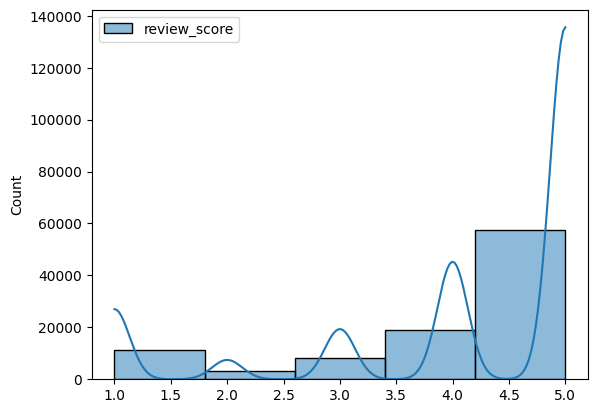

In [60]:
sns.histplot(data=order_reviews_df,bins=5,kde=True)

## Summary of order review Analysis

* Order Review has 87656 i.e 88.3% missing values in review_comment_title, 58247 i.e 58.7% in review_comment_message with 0 duplicated values.
* review_creation_date and review_answer_timestamp are in string we have to conver this into datetime datatype.
* All column are not unique.
* review_id(98410),order_id(98673),review_score(5),review_comment_title(4527),review_comment_message(36159),review_creation_date(636),review_answer_timestamp(98248)
- (***note:*** The column name with there unique/distinct value count is given).
* Most of customer giving 5 star reviews.

### Data Cleaning

In [61]:
order_reviews_df['review_comment_title'] = order_reviews_df['review_comment_title'].fillna('No Title')
order_reviews_df['review_comment_message'] = order_reviews_df['review_comment_message'].fillna('No Message')

In [62]:
order_reviews_df.isnull().sum()

review_id                  0
order_id                   0
review_score               0
review_comment_title       0
review_comment_message     0
review_creation_date       0
review_answer_timestamp    0
dtype: int64

In [63]:
order_reviews_df['review_answer_timestamp']= pd.to_datetime(order_reviews_df['review_answer_timestamp'])
order_reviews_df['review_creation_date']= pd.to_datetime(order_reviews_df['review_creation_date'])

In [64]:
order_reviews_df.dtypes

review_id                             str
order_id                              str
review_score                        int64
review_comment_title                  str
review_comment_message                str
review_creation_date       datetime64[us]
review_answer_timestamp    datetime64[us]
dtype: object

In [65]:
order_reviews_df.to_csv('..\\Cleaned_Dataset\\cleaned_order_reviews.csv',index=False)

## 📋 Orders Dataframe Analysis

In [66]:
orders_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


In [67]:
orders_df.describe().T

,count,unique,top,freq
order_id,99441,99441,e481f51cbdc54678b7cc49136f2d6af7,1
customer_id,99441,99441,9ef432eb6251297304e76186b10a928d,1
order_status,99441,8,delivered,96478
order_purchase_timestamp,99441,98875,2018-03-31 15:08:21,3
order_approved_at,99281,90733,2018-02-27 04:31:10,9
order_delivered_carrier_date,97658,81018,2018-05-09 15:48:00,47
order_delivered_customer_date,96476,95664,2018-05-14 20:02:44,3
order_estimated_delivery_date,99441,459,2017-12-20 00:00:00,522


In [68]:
missing_summary={
    'Missing Count': orders_df.isnull().sum(),
    'Missing Percentage': orders_df.isnull().mean()
}

print(f'Missing Count:\n{missing_summary["Missing Count"]}\n\nMissing Percentage:\n{missing_summary["Missing Percentage"]}')

Missing Count:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Missing Percentage:
order_id                         0.000000
customer_id                      0.000000
order_status                     0.000000
order_purchase_timestamp         0.000000
order_approved_at                0.001609
order_delivered_carrier_date     0.017930
order_delivered_customer_date    0.029817
order_estimated_delivery_date    0.000000
dtype: float64


In [69]:
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [70]:
orders_df.tail()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00
99440,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-03-08 20:57:30,2018-03-09 11:20:28,2018-03-09 22:11:59,2018-03-16 13:08:30,2018-04-03 00:00:00


In [71]:
for i in orders_df.columns:
    orders_df[i].is_unique
    if orders_df[i].is_unique==True:
        print(f'{i} is unique')
    if orders_df[i].is_unique==False:
        print(f'{i} is not unique')

order_id is unique
customer_id is unique
order_status is not unique
order_purchase_timestamp is not unique
order_approved_at is not unique
order_delivered_carrier_date is not unique
order_delivered_customer_date is not unique
order_estimated_delivery_date is not unique


In [72]:
orders_df.nunique()

order_id                         99441
customer_id                      99441
order_status                         8
order_purchase_timestamp         98875
order_approved_at                90733
order_delivered_carrier_date     81018
order_delivered_customer_date    95664
order_estimated_delivery_date      459
dtype: int64

<Axes: xlabel='count', ylabel='order_status'>

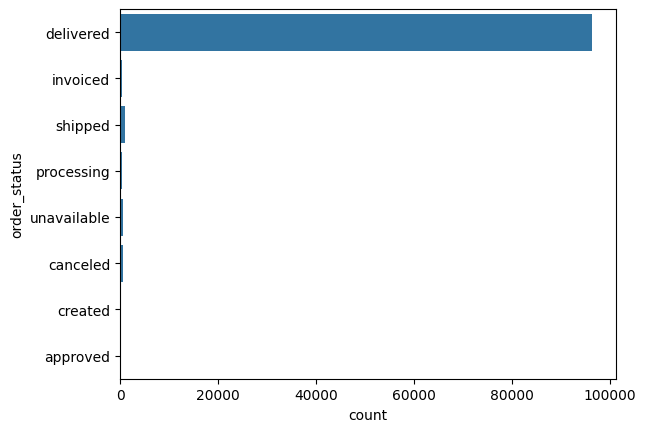

In [73]:
sns.countplot(data=orders_df['order_status'])

### Summary of Order Data Analysis

* Orders has 160 i.e 0.001% missing values in order_approved_at, 1783 i.e 0.017% in order_delivered_carrier_date, 2965 i.e 0.029% in order_delivered_customer_date with no duplicated values
* we have to convert order_purchase_timestamp,order_approved_at,
order_delivered_carrier_date,order_delivered_customer_date,
order_estimated_delivery_date into datetime format that is currently in string format
* order_id, ciustomer_id is unique and other column are not unique
* order_id(99441),customer_id(99441),order_status(8),order_purchase_timestamp(98875),order_approved_at(90733),order_delivered_carrier_date(81018),order_delivered_customer_date(95664),order_estimated_delivery_date(459)
* The chart show most of orders are delivered sucessfully

### Data Cleaning

In [74]:
datetime_col = ['order_purchase_timestamp','order_approved_at','order_delivered_carrier_date','order_delivered_customer_date','order_estimated_delivery_date']
for i in datetime_col:
    orders_df[i]= pd.to_datetime(orders_df[i])
orders_df.dtypes

order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

In [75]:
orders_df['delivery_missing_flag'] = orders_df['order_delivered_customer_date'].isnull().astype(int)

median_delivery_days = (orders_df['order_delivered_customer_date'] - orders_df['order_purchase_timestamp']).dt.days.median()

anomaly_mask = (orders_df['order_status'] == 'delivered') & (orders_df['order_delivered_customer_date'].isnull())

orders_df.loc[anomaly_mask, 'order_delivered_customer_date'] = orders_df.loc[anomaly_mask, 'order_purchase_timestamp'] + pd.to_timedelta(median_delivery_days, unit='D')

In [76]:
missing_summary={
    'Missing Count': orders_df.isnull().sum(),
    'Missing Percentage': orders_df.isnull().mean()
}

print(f'Missing Count:\n{missing_summary["Missing Count"]}\n\nMissing Percentage:\n{missing_summary["Missing Percentage"]}')

Missing Count:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2957
order_estimated_delivery_date       0
delivery_missing_flag               0
dtype: int64

Missing Percentage:
order_id                         0.000000
customer_id                      0.000000
order_status                     0.000000
order_purchase_timestamp         0.000000
order_approved_at                0.001609
order_delivered_carrier_date     0.017930
order_delivered_customer_date    0.029736
order_estimated_delivery_date    0.000000
delivery_missing_flag            0.000000
dtype: float64


In [77]:
orders_df.to_csv('..\\Cleaned_Dataset\\cleaned_order.csv',index=False)

## 💳 Order Payments Dataframe Analysis

In [78]:
order_payments_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  str    
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  str    
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 4.0 MB


In [79]:
order_payments_df.describe().T

,count,mean,std,min,25%,50%,75%,max
payment_sequential,103886.0,1.092679,0.706584,1.0,1.00,1.0,1.0000,29.00
payment_installments,103886.0,2.853349,2.687051,0.0,1.00,1.0,4.0000,24.00
payment_value,103886.0,154.100380,217.494064,0.0,56.79,100.0,171.8375,13664.08


In [80]:
missing_summary={
    'Missing Count': order_payments_df.isnull().sum(),
    'Missing Percentage': order_payments_df.isnull().mean() * 100
}

print(f'Missing Count:\n{missing_summary["Missing Count"]}\n\nMissing Percentage:\n{missing_summary["Missing Percentage"]}')

Missing Count:
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

Missing Percentage:
order_id                0.0
payment_sequential      0.0
payment_type            0.0
payment_installments    0.0
payment_value           0.0
dtype: float64


In [81]:
order_payments_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [82]:
order_payments_df.tail()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
103881,0406037ad97740d563a178ecc7a2075c,1,boleto,1,363.31
103882,7b905861d7c825891d6347454ea7863f,1,credit_card,2,96.80
103883,32609bbb3dd69b3c066a6860554a77bf,1,credit_card,1,47.77
103884,b8b61059626efa996a60be9bb9320e10,1,credit_card,5,369.54
103885,28bbae6599b09d39ca406b747b6632b1,1,boleto,1,191.58


In [83]:
for i in order_payments_df.columns:
    order_payments_df[i].is_unique
    if order_payments_df[i].is_unique ==True:
        print(f'{i} is unique')
    if order_payments_df[i].is_unique == False:
        print(f'{i} is not unique')

order_id is not unique
payment_sequential is not unique
payment_type is not unique
payment_installments is not unique
payment_value is not unique


In [84]:
order_payments_df.nunique()

order_id                99440
payment_sequential         29
payment_type                5
payment_installments       24
payment_value           29077
dtype: int64

<Axes: xlabel='payment_value', ylabel='payment_type'>

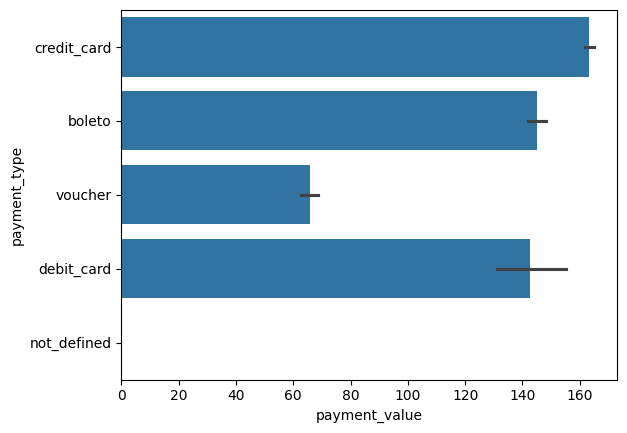

In [85]:
sns.barplot(data=order_payments_df,x='payment_value',y='payment_type')

### Summary of order payment data Analysis

* order payment has 0% missing values with 0 duplicates.
* All columns are not unique.
* order_id(99440), payment_sequential(29), payment_type(5), payment_installments(24), payment_value(29077)
* Most of paymentts made by credit card followed by debit card.

### Data Cleaning

In [86]:
missing_order = set(orders_df['order_id']) - set(order_payments_df['order_id'])
print("Order with no payment record:", missing_order)

Order with no payment record: {'bfbd0f9bdef84302105ad712db648a6c'}


In [87]:
order_payments_df[order_payments_df['order_id']=='bfbd0f9bdef84302105ad712db648a6c']

,order_id,payment_sequential,payment_type,payment_installments,payment_value


In [88]:
orders_df[orders_df['order_id']=='bfbd0f9bdef84302105ad712db648a6c']

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_missing_flag
30710,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04,0


In [89]:
customer_df[customer_df['customer_id']=='86dc2ffce2dfff336de2f386a786e574']

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
21125,86dc2ffce2dfff336de2f386a786e574,830d5b7aaa3b6f1e9ad63703bec97d23,14600,sao joaquim da barra,SP


In [90]:
print(order_payments_df[['payment_sequential', 'payment_installments']].min())

payment_sequential      1
payment_installments    0
dtype: int64


In [91]:
order_payments_df['payment_installments']=order_payments_df['payment_installments'].replace(0,1)

In [92]:
order_payments_df[order_payments_df['payment_type']=='not_defined']

,order_id,payment_sequential,payment_type,payment_installments,payment_value
51280,4637ca194b6387e2d538dc89b124b0ee,1,not_defined,1,0.0
57411,00b1cb0320190ca0daa2c88b35206009,1,not_defined,1,0.0
94427,c8c528189310eaa44a745b8d9d26908b,1,not_defined,1,0.0


In [93]:
order_payments_df = order_payments_df[order_payments_df['payment_type'] != 'not_defined']

In [94]:
order_payments_df.to_csv('..\\Cleaned_Dataset\\cleaned_order_payment.csv',index=False)

## 🏷️ Products Dataframe Analysis

In [95]:
products_df=products_df.merge(product_category_name_translation_df,'left')

In [96]:
products_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   product_id                     32951 non-null  str    
 1   product_category_name          32341 non-null  str    
 2   product_name_lenght            32341 non-null  float64
 3   product_description_lenght     32341 non-null  float64
 4   product_photos_qty             32341 non-null  float64
 5   product_weight_g               32949 non-null  float64
 6   product_length_cm              32949 non-null  float64
 7   product_height_cm              32949 non-null  float64
 8   product_width_cm               32949 non-null  float64
 9   product_category_name_english  32328 non-null  str    
dtypes: float64(7), str(3)
memory usage: 2.5 MB


In [97]:
products_df.describe().T

,count,mean,std,min,25%,50%,75%,max
product_name_lenght,32341.0,48.476949,10.245741,5.0,42.0,51.0,57.0,76.0
product_description_lenght,32341.0,771.495285,635.115225,4.0,339.0,595.0,972.0,3992.0
product_photos_qty,32341.0,2.188986,1.736766,1.0,1.0,1.0,3.0,20.0
product_weight_g,32949.0,2276.472488,4282.038731,0.0,300.0,700.0,1900.0,40425.0
product_length_cm,32949.0,30.815078,16.914458,7.0,18.0,25.0,38.0,105.0
product_height_cm,32949.0,16.937661,13.637554,2.0,8.0,13.0,21.0,105.0
product_width_cm,32949.0,23.196728,12.079047,6.0,15.0,20.0,30.0,118.0


In [98]:
missing_summary={
    'Missing Count': products_df.isnull().sum(),
    'Missing Percentage': products_df.isnull().mean() *100
}

print(f'Missing Count:\n{missing_summary["Missing Count"]}\n\nMissing Percentage:\n{missing_summary["Missing Percentage"]}')

Missing Count:
product_id                         0
product_category_name            610
product_name_lenght              610
product_description_lenght       610
product_photos_qty               610
product_weight_g                   2
product_length_cm                  2
product_height_cm                  2
product_width_cm                   2
product_category_name_english    623
dtype: int64

Missing Percentage:
product_id                       0.000000
product_category_name            1.851234
product_name_lenght              1.851234
product_description_lenght       1.851234
product_photos_qty               1.851234
product_weight_g                 0.006070
product_length_cm                0.006070
product_height_cm                0.006070
product_width_cm                 0.006070
product_category_name_english    1.890686
dtype: float64


In [99]:
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares


In [100]:
products_df.tail()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,45.0,67.0,2.0,12300.0,40.0,40.0,40.0,furniture_decor
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,41.0,971.0,1.0,1700.0,16.0,19.0,16.0,construction_tools_lights
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,50.0,799.0,1.0,1400.0,27.0,7.0,27.0,bed_bath_table
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,60.0,156.0,2.0,700.0,31.0,13.0,20.0,computers_accessories
32950,106392145fca363410d287a815be6de4,cama_mesa_banho,58.0,309.0,1.0,2083.0,12.0,2.0,7.0,bed_bath_table


In [101]:
for i in products_df.columns:
    products_df[i].is_unique
    if products_df[i].is_unique == True:
        print(f'{i} is unique')
    if products_df[i].is_unique == False:
        print(f'{i} is not unique')

product_id is unique
product_category_name is not unique
product_name_lenght is not unique
product_description_lenght is not unique
product_photos_qty is not unique
product_weight_g is not unique
product_length_cm is not unique
product_height_cm is not unique
product_width_cm is not unique
product_category_name_english is not unique


In [102]:
products_df.nunique()

product_id                       32951
product_category_name               73
product_name_lenght                 66
product_description_lenght        2960
product_photos_qty                  19
product_weight_g                  2204
product_length_cm                   99
product_height_cm                  102
product_width_cm                    95
product_category_name_english       71
dtype: int64

### Summary of product Analysis

* Product has 610 i.e 1.85% in product_category_name, product_name_lenght, product_description_lenght, product_photos_qty missing
* 2 i.e 0.006% in product_weight_g, product_length_cm, product_height_cm, product_width_cm missing.
* 623 i.e 1.89% in product_category_name_english are missing
* there are 0 duplicated values.
* product_id is unique and other columns are not unique.
* product_id(32951), product_category_name(73), product_name_lenght(66), product_description_lenght(2960), product_photos_qty(19), product_weight_g(2204), product_length_cm(99), product_height_cm(102), product_width_cm(95), product_category_name_english(71) 

### Data Cleaning

In [103]:
products_df[products_df['product_category_name'].isnull()].shape

(610, 10)

In [104]:
products_df['product_category_name'] = products_df['product_category_name'].fillna('unknown')
num_col = ['product_photos_qty','product_description_lenght','product_name_lenght','product_weight_g','product_length_cm','product_height_cm','product_width_cm']
for col in num_col:
    products_df[col]=products_df[col].fillna(0)

In [105]:
missing_trans = products_df[products_df['product_category_name_english'].isnull()]['product_category_name'].unique()
print("Categories missing English translations:", missing_trans)

Categories missing English translations: <StringArray>
['unknown', 'pc_gamer', 'portateis_cozinha_e_preparadores_de_alimentos']
Length: 3, dtype: str


In [106]:
products_df.loc[products_df['product_category_name']=='pc_gamer','product_category_name_english']='pc_gamer'
products_df.loc[products_df['product_category_name']=='portateis_cozinha_e_preparadores_de_alimentos','product_category_name_english']='kitchen appliances and food prep equipment'
products_df.loc[products_df['product_category_name']=='unknown','product_category_name_english']='unknown'

In [107]:
products_df.to_csv('..\\Cleaned_Dataset\\cleaned_products.csv',index=False)

## 🏪 Sellers Dataframe Analysis

In [108]:
sellers_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   seller_id               3095 non-null   str  
 1   seller_zip_code_prefix  3095 non-null   int64
 2   seller_city             3095 non-null   str  
 3   seller_state            3095 non-null   str  
dtypes: int64(1), str(3)
memory usage: 96.8 KB


In [109]:
sellers_df.describe().T

,count,mean,std,min,25%,50%,75%,max
seller_zip_code_prefix,3095.0,32291.059451,32713.45383,1001.0,7093.5,14940.0,64552.5,99730.0


In [110]:
missing_summary={
    'Missing Count': sellers_df.isnull().sum(),
    'Missing Percentage': sellers_df.isnull().mean() *100
}

print(f'Missing Count:\n{missing_summary["Missing Count"]}\n\nMissing Percentage:\n{missing_summary["Missing Percentage"]}')

Missing Count:
seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

Missing Percentage:
seller_id                 0.0
seller_zip_code_prefix    0.0
seller_city               0.0
seller_state              0.0
dtype: float64


In [111]:
sellers_df.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [112]:
sellers_df.tail()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
3090,98dddbc4601dd4443ca174359b237166,87111,sarandi,PR
3091,f8201cab383e484733266d1906e2fdfa,88137,palhoca,SC
3092,74871d19219c7d518d0090283e03c137,4650,sao paulo,SP
3093,e603cf3fec55f8697c9059638d6c8eb5,96080,pelotas,RS
3094,9e25199f6ef7e7c347120ff175652c3b,12051,taubate,SP


In [113]:
for i in sellers_df.columns:
    sellers_df[i].is_unique
    if sellers_df[i].is_unique == True:
        print(f'{i} is unique')
    if sellers_df[i].is_unique == False:
        print(f'{i} is not unique')

seller_id is unique
seller_zip_code_prefix is not unique
seller_city is not unique
seller_state is not unique


In [114]:
sellers_df.nunique()

seller_id                 3095
seller_zip_code_prefix    2246
seller_city                611
seller_state                23
dtype: int64

### Summary of Seller data Analysis

* The seller data has 0% missing value i.e 0 duplicate values.
* seller_id is unique.
* seller_id(3095), seller_zip_code_prefix(2246), seller_city(611), seller_state(23)

### Data Cleaning

In [115]:
sellers_df.to_csv('..\\Cleaned_Dataset\\cleaned_seller.csv',index=False)